In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
data_dir = '/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80609'
fn_list = glob.glob(os.path.join(data_dir, 'zbest-*.fits'))

In [4]:
fn_list

['/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80609/zbest-3-80609.fits',
 '/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80609/zbest-0-80609.fits',
 '/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80609/zbest-9-80609.fits',
 '/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80609/zbest-8-80609.fits',
 '/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80609/zbest-7-80609.fits',
 '/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80609/zbest-6-80609.fits',
 '/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80609/zbest-2-80609.fits',
 '/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80609/zbest-5-80609.fits',
 '/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80609/zbest-4-80609.fits',
 '/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80609/zbest-1-80609.fits']

In [5]:
zbest = []
for fn in fn_list:
    tmp1 = Table.read(fn, hdu='ZBEST')
    tmp2 = Table.read(fn, hdu='FIBERMAP')
    tmp = join(tmp1, tmp2, keys='TARGETID', metadata_conflicts='silent')
    zbest.append(tmp)
zbest = vstack(zbest)
print(len(zbest))

5000


In [6]:
zbest[:5]

TARGETID,CHI2,COEFF [10],Z,ZERR,ZWARN,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,NUMEXP,NUMTILE,PETAL_LOC,DEVICE_LOC,LOCATION,FIBER,FIBERSTATUS,TARGET_RA,TARGET_DEC,PMRA,PMDEC,REF_EPOCH,LAMBDA_REF,FA_TARGET,FA_TYPE,OBJTYPE,FIBERASSIGN_X,FIBERASSIGN_Y,NUMTARGET,PRIORITY,SUBPRIORITY,OBSCONDITIONS,MORPHTYPE,FLUX_G,FLUX_R,FLUX_Z,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,REF_ID,REF_CAT,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_RP_MEAN_MAG,PARALLAX,EBV,FLUX_W1,FLUX_W2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,MASKBITS,SERSIC,SHAPE_R,SHAPE_E1,SHAPE_E2,PHOTSYS,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,PRIORITY_INIT,NUMOBS_INIT,RELEASE,BRICKID,BRICKNAME,BRICK_OBJID,BLOBDIST,FIBERFLUX_IVAR_G,FIBERFLUX_IVAR_R,FIBERFLUX_IVAR_Z,DESI_TARGET,BGS_TARGET,MWS_TARGET,HPXPIXEL,NUM_ITER,FIBER_X,FIBER_Y,MEAN_DELTA_X,MEAN_DELTA_Y,FIBER_RA,FIBER_DEC,COADD_NUMEXP,RMS_DELTA_X,RMS_DELTA_Y,FIRST_FIBER,LAST_FIBER,NUM_FIBER
int64,float64,float64,float64,float64,int64,int64,bytes6,bytes20,int64,float64,int32,int32,int16,int32,int64,int32,int32,float64,float64,float32,float32,float32,float32,int64,uint8,bytes3,float32,float32,int16,int32,float64,int32,bytes4,float32,float32,float32,float32,float32,float32,int64,bytes2,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,bytes1,int64,int64,int64,int64,int64,int32,int32,bytes8,int32,float32,float32,float32,float32,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,int16,float64,float64,int64,int64,int64
39627841578467775,35377.29297590256,-0.3657814372540345 .. 1.3119578097528644,1.0419504492120744,6.237503856338444e-05,4,7759,GALAXY,,10,5.270341157913208,0,0,3,462,3462,1612,0,148.51949993858793,2.369190239966562,0.0,0.0,2020.9487,5400.0,100663393,1,TGT,405.6465,42.063255,0,3200,0.27727619208590604,1,REX,0.014247058,0.37670425,2.511673,1656.7931,688.02563,92.69866,0,,0.0,0.0,0.0,0.0,0.03827628,18.39737,18.159477,0.008824458,0.23332614,1.5557004,0.012935985,0.24296175,1.56918,0,1.0,0.34449497,0.0,0.0,S,100663393,0,0,3200,1,0,0,,0,0.0,0.0,0.0,0.0,0,0,0,0,2,405.581,41.997,-0.002466666666666666,0.0012000000000000001,0.0,0.0,15,0.008544003745317531,0.006324555320336759,1612,1612,1
39627841578467849,25510.390614509583,7.87222282345184 .. -0.9177242581273636,1.0268909594209739,1.7900650549261462e-05,0,7758,GALAXY,,10,262.99039101600647,0,0,3,440,3440,1629,0,148.52301462049059,2.304584207052623,0.0,0.0,2020.9487,5400.0,36032920187604742,1,TGT,404.59998,25.656862,0,3400,0.4933697633491422,3,EXP,0.48371822,0.56248206,1.2754387,1737.5388,827.7832,166.5453,0,,0.0,0.0,0.0,0.0,0.04696187,1.0590832,2.6977272,0.3388291,0.39400062,0.8934039,0.3388291,0.39400062,0.8934039,0,1.0,0.27198982,0.18173137,0.16071016,S,36032920187604742,0,0,3400,1,0,0,,0,0.0,0.0,0.0,0.0,0,0,0,0,2,404.535,25.593,-0.0026,0.0015333333333333334,0.0,0.0,15,0.008370583412562511,0.007028513356322232,1629,1629,1
39627841578467949,23924.38133573532,99.20448959705432 .. 3.363934655529898,0.757757756346504,1.6089839592350557e-05,0,7757,GALAXY,,10,1400.5999507904053,0,0,3,416,3416,1626,0,148.52752015818845,2.223663959257791,0.0,0.0,2020.9487,5400.0,824633721602,1,TGT,403.34146,5.130425,0,3000,0.9544033845306858,3,DEV,1.0246618,2.1062038,4.450776,535.2924,229.33278,42.13833,0,,0.0,0.0,0.0,0.0,0.048062038,12.688103,7.0522456,0.36512977,0.7505284,1.5859975,0.38861004,0.79372585,1.6608359,0,4.0,1.1237068,0.19485651,-0.16985705,S,824633721602,0,0,3000,1,0,0,,0,0.0,0.0,0.0,0.0,0,0,0,0,2,403.275,5.07,-0.003999999999999999,0.003933333333333333,0.0,0.0,15,0.009444575162494076,0.008354639429682169,1626,1626,1
39627841578468321,22194.550537526608,264.35377569012724 .. 17.761194068564325,0.5802952783947467,3.001223618903301e-05,0,7752,GALAXY,,10,4171.566809996963,0,0,3,441,3441,1632,0,148.54243918989326,2.3272479548307357,0.0,0.0,2020.9487,5400.0,1152921504640401441,1,TGT,399.28275,31.363775,0,3200,0.35720732697701

In [7]:
# SV1 target bits
bitvalues = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 53, 54, 55, 56, 57, 32, 33, 34, 35, 36, 37, 49, 50, 51, 52, 60, 61, 62]
bitnames = ['LRG', 'ELG', 'QSO', 'LRG_OPT', 'LRG_IR', 'LRG_SV_OPT', 'LRG_SV_IR', 'LOWZ_FILLER', 'ELG_SV_GTOT', 'ELG_SV_GFIB', 'ELG_FDR_GTOT', 'ELG_FDR_GFIB', 'QSO_COLOR_4PASS', 'QSO_RF_4PASS', 'QSO_COLOR_8PASS', 'QSO_RF_8PASS', 'QSO_HZ_F', 'QSO_Z5', 'LRG_OPT_NORTH', 'LRG_IR_NORTH', 'LRG_SV_OPT_NORTH', 'LRG_SV_IR_NORTH', 'LOWZ_FILLER_NORTH', 'LRG_OPT_SOUTH', 'LRG_IR_SOUTH', 'LRG_SV_OPT_SOUTH', 'LRG_SV_IR_SOUTH', 'LOWZ_FILLER_SOUTH', 'ELG_SV_GTOT_NORTH', 'ELG_SV_GFIB_NORTH', 'ELG_FDR_GTOT_NORTH', 'ELG_FDR_GFIB_NORTH', 'ELG_SV_GTOT_SOUTH', 'ELG_SV_GFIB_SOUTH', 'ELG_FDR_GTOT_SOUTH', 'ELG_FDR_GFIB_SOUTH', 'QSO_COLOR_4PASS_NORTH', 'QSO_RF_4PASS_NORTH', 'QSO_COLOR_8PASS_NORTH', 'QSO_RF_8PASS_NORTH', 'QSO_HZ_F_NORTH', 'QSO_Z5_NORTH', 'QSO_COLOR_4PASS_SOUTH', 'QSO_RF_4PASS_SOUTH', 'QSO_COLOR_8PASS_SOUTH', 'QSO_RF_8PASS_SOUTH', 'QSO_HZ_F_SOUTH', 'QSO_Z5_SOUTH', 'SKY', 'STD_FAINT', 'STD_WD', 'STD_BRIGHT', 'BAD_SKY', 'SUPP_SKY', 'NO_TARGET', 'BRIGHT_OBJECT', 'IN_BRIGHT_OBJECT', 'NEAR_BRIGHT_OBJECT', 'BGS_ANY', 'MWS_ANY', 'SCND_ANY']

def bitmask_summary(mask_values, names, bits):
    mask_values = np.array(mask_values, dtype=np.uint64)
    t = Table()
    t['name'] = names
    t['bit'] = bits
    t['count'] = 0
    for index in range(len(bits)):
        bit = bits[index]
        t['count'][index] = np.sum(mask_values & (2**bit)>0)
    t['frac (%)'] = t['count']/len(mask_values)*100
    t['frac (%)'].format = "%.3f"
    return t

In [8]:
t = bitmask_summary(zbest['SV1_DESI_TARGET'], bitnames, bitvalues)
t.pprint(max_lines=-1)

         name         bit count frac (%)
--------------------- --- ----- --------
                  LRG   0  2125   42.500
                  ELG   1  1317   26.340
                  QSO   2  1341   26.820
              LRG_OPT   3   528   10.560
               LRG_IR   4   525   10.500
           LRG_SV_OPT   5  1626   32.520
            LRG_SV_IR   6  1828   36.560
          LOWZ_FILLER   7     0    0.000
          ELG_SV_GTOT   8  1026   20.520
          ELG_SV_GFIB   9  1219   24.380
         ELG_FDR_GTOT  10   537   10.740
         ELG_FDR_GFIB  11   668   13.360
      QSO_COLOR_4PASS  12   360    7.200
         QSO_RF_4PASS  13   669   13.380
      QSO_COLOR_8PASS  14   214    4.280
         QSO_RF_8PASS  15   366    7.320
             QSO_HZ_F  16   231    4.620
               QSO_Z5  17    44    0.880
        LRG_OPT_NORTH  18     0    0.000
         LRG_IR_NORTH  19     0    0.000
     LRG_SV_OPT_NORTH  20     0    0.000
      LRG_SV_IR_NORTH  21     0    0.000
    LOWZ_FILLER_

In [9]:
lrg_opt = zbest['SV1_DESI_TARGET'] & 2**3>0
lrg_ir = zbest['SV1_DESI_TARGET'] & 2**4>0
lrg_sv = zbest['SV1_DESI_TARGET'] & 2**0>0
print(np.sum(lrg_opt))
print(np.sum(lrg_ir))
print(np.sum(lrg_sv))
print()

ts_qso = (zbest['SV1_DESI_TARGET'] & 2**2>0)
print(np.sum(ts_qso))
print(np.sum(ts_qso & lrg_sv))
print(np.sum(ts_qso & lrg_opt))

ts_sky = (zbest['DESI_TARGET'] & 2**32>0)
print(np.sum(ts_sky))

528
525
2125

1341
36
1
800


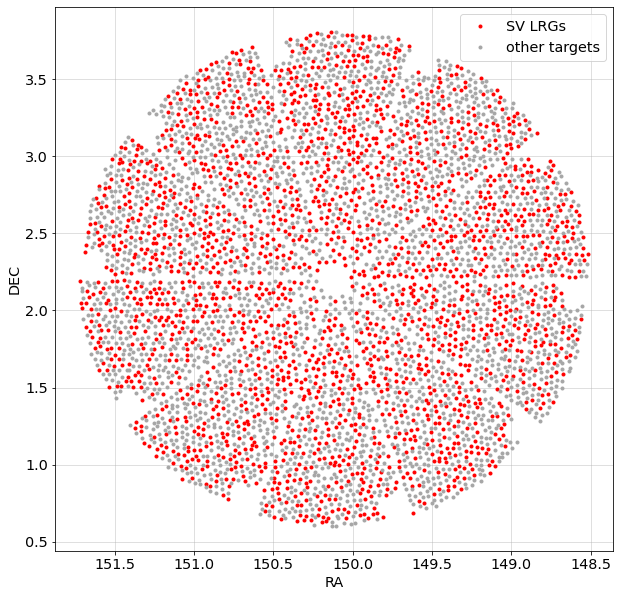

In [10]:
# mask = np.ones(len(zbest), dtype=bool)
plt.figure(figsize=(10, 10))
plt.plot(zbest['TARGET_RA'][lrg_sv], zbest['TARGET_DEC'][lrg_sv], 'r.', ms=6, label='SV LRGs')
plt.plot(zbest['TARGET_RA'][~lrg_sv], zbest['TARGET_DEC'][~lrg_sv], '.', ms=6, label='other targets', color='0.65', alpha=1)
plt.xlabel('RA')
plt.ylabel('DEC')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

In [11]:
# Remove FIBERSTATUS!=0 fibers
mask = zbest['FIBERSTATUS']!=0
print(np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
zbest = zbest[~mask]

# Remove "no data" fibers
nodata = zbest['ZWARN'] & 2**9>0
print(np.sum(nodata), np.sum(~nodata), np.sum(nodata)/len(nodata))
zbest = zbest[~nodata]

print(len(zbest))

801 4199 0.1602
0 4199 0.0
4199


In [12]:
lrg_opt = zbest['SV1_DESI_TARGET'] & 2**3>0
lrg_ir = zbest['SV1_DESI_TARGET'] & 2**4>0
lrg_sv = (zbest['SV1_DESI_TARGET'] & 2**0>0)
print(np.sum(lrg_opt))
print(np.sum(lrg_ir))
print(np.sum(lrg_sv))
print()

ts_qso = (zbest['SV1_DESI_TARGET'] & 2**2>0)
print(np.sum(ts_qso))
print(np.sum(ts_qso & lrg_sv))
print(np.sum(ts_qso & lrg_opt))

434
435
1790

1123
29
1


In [13]:
mask_zwarn = zbest['ZWARN']==0
print(np.sum((~mask_zwarn) & lrg_opt), np.sum((~mask_zwarn) & lrg_opt)/np.sum(lrg_opt))
print(np.sum((~mask_zwarn) & lrg_ir), np.sum((~mask_zwarn) & lrg_ir)/np.sum(lrg_ir))
print(np.sum((~mask_zwarn) & lrg_sv), np.sum((~mask_zwarn) & lrg_sv)/np.sum(lrg_sv))

0 0.0
0 0.0
17 0.009497206703910615


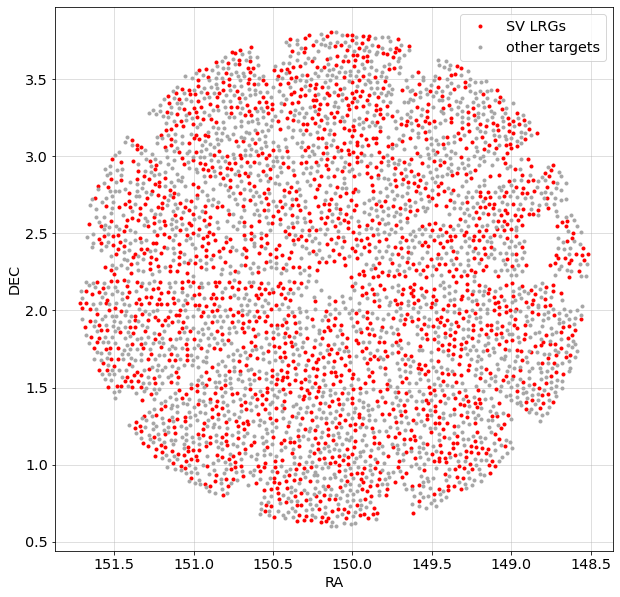

In [14]:
# mask = np.ones(len(zbest), dtype=bool)
plt.figure(figsize=(10, 10))
plt.plot(zbest['TARGET_RA'][lrg_sv], zbest['TARGET_DEC'][lrg_sv], 'r.', ms=6, label='SV LRGs')
plt.plot(zbest['TARGET_RA'][~lrg_sv], zbest['TARGET_DEC'][~lrg_sv], '.', ms=6, label='other targets', color='0.65', alpha=1)
plt.xlabel('RA')
plt.ylabel('DEC')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

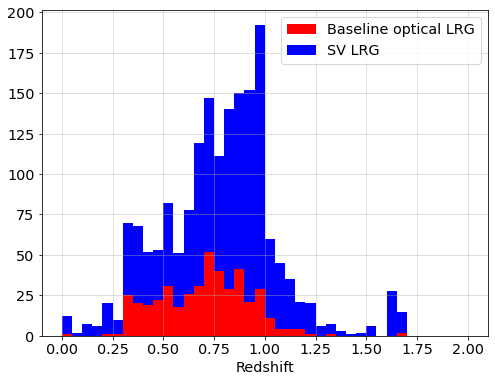

In [15]:
plt.figure(figsize=(8, 6))
plt.hist(zbest['Z'][lrg_opt & mask_zwarn], bins=40, range=(0, 2.0), color='red', label=['Baseline optical LRG'], zorder=1)
plt.hist(zbest['Z'][lrg_sv & mask_zwarn], bins=40, range=(0, 2.0), color='blue', label=['SV LRG'], zorder=0)
plt.xlabel('Redshift')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.show()

No ZWARN cut:


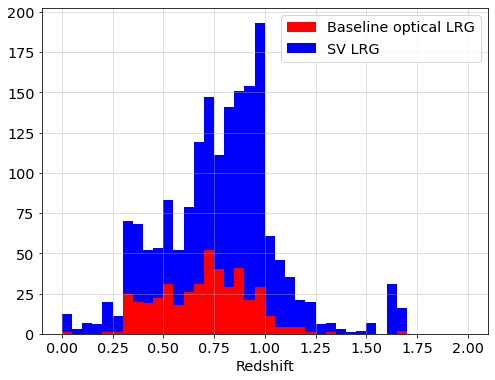

In [16]:
print('No ZWARN cut:')
plt.figure(figsize=(8, 6))
plt.hist(zbest['Z'][lrg_opt], bins=40, range=(0, 2.0), color='red', label=['Baseline optical LRG'], zorder=1)
plt.hist(zbest['Z'][lrg_sv], bins=40, range=(0, 2.0), color='blue', label=['SV LRG'], zorder=0)
plt.xlabel('Redshift')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.show()

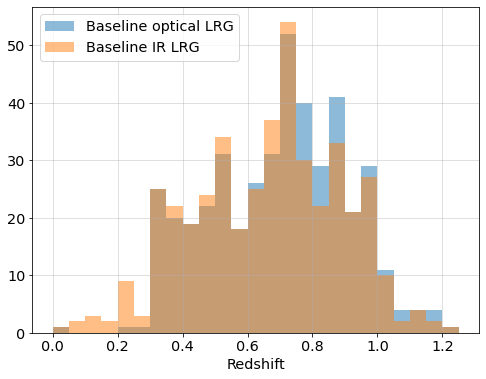

In [17]:
plt.figure(figsize=(8, 6))
plt.hist(zbest['Z'][lrg_opt & mask_zwarn], bins=25, range=(0, 1.25), label=['Baseline optical LRG'], alpha=0.5)
plt.hist(zbest['Z'][lrg_ir & mask_zwarn], bins=25, range=(0, 1.25), label=['Baseline IR LRG'], alpha=0.5)
plt.xlabel('Redshift')
plt.legend(loc='upper left')
plt.grid(alpha=0.5)
plt.show()

--------
# Stellar contamination

In [18]:
print('LRG_OPT:')
mask = lrg_opt & mask_zwarn
t = Table()
t['type'], t['counts'] = np.unique(zbest['SPECTYPE'][mask], return_counts=True)
t['frac (%)'] = t['counts']/np.sum(mask)*100
t['frac (%)'].format = '%.1f'
# t.sort('counts')
t

LRG_OPT:


type,counts,frac (%)
bytes6,int64,float64
GALAXY,430,99.1
QSO,4,0.9


In [19]:
print('LRG_IR:')
mask = lrg_ir & mask_zwarn
t = Table()
t['type'], t['counts'] = np.unique(zbest['SPECTYPE'][mask], return_counts=True)
t['frac (%)'] = t['counts']/np.sum(mask)*100
t['frac (%)'].format = '%.1f'
# t.sort('counts')
t

LRG_IR:


type,counts,frac (%)
bytes6,int64,float64
GALAXY,419,96.3
QSO,15,3.4
STAR,1,0.2


In [20]:
print('LRG_SV:')
mask = lrg_sv & mask_zwarn
t = Table()
t['type'], t['counts'] = np.unique(zbest['SPECTYPE'][mask], return_counts=True)
t['frac (%)'] = t['counts']/np.sum(mask)*100
t['frac (%)'].format = '%.1f'
# t.sort('counts')
t

LRG_SV:


type,counts,frac (%)
bytes6,int64,float64
GALAXY,1723,97.2
QSO,39,2.2
STAR,11,0.6


In [21]:
mask_star = zbest['SPECTYPE']=='STAR'
mask_gal = zbest['SPECTYPE']=='GALAXY'
mask_qso = zbest['SPECTYPE']=='QSO'

In [22]:
mask = lrg_sv & mask_star & mask_zwarn
print(np.sum(mask))
mask1 = mask & ((zbest['MASKBITS'] & 2**11>0) | (zbest['MASKBITS'] & 2**8>0))
print(np.sum(mask1))

11
2


In [23]:
mask = lrg_opt & mask_star & mask_zwarn
print(np.sum(mask))
mask1 = mask & ((zbest['MASKBITS'] & 2**11>0) | (zbest['MASKBITS'] & 2**8>0))
print(np.sum(mask1))

0
0


In [24]:
mask = lrg_sv & mask_star & mask_zwarn
zbest[mask]

TARGETID,CHI2,COEFF [10],Z,ZERR,ZWARN,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,NUMEXP,NUMTILE,PETAL_LOC,DEVICE_LOC,LOCATION,FIBER,FIBERSTATUS,TARGET_RA,TARGET_DEC,PMRA,PMDEC,REF_EPOCH,LAMBDA_REF,FA_TARGET,FA_TYPE,OBJTYPE,FIBERASSIGN_X,FIBERASSIGN_Y,NUMTARGET,PRIORITY,SUBPRIORITY,OBSCONDITIONS,MORPHTYPE,FLUX_G,FLUX_R,FLUX_Z,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,REF_ID,REF_CAT,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_RP_MEAN_MAG,PARALLAX,EBV,FLUX_W1,FLUX_W2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,MASKBITS,SERSIC,SHAPE_R,SHAPE_E1,SHAPE_E2,PHOTSYS,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,PRIORITY_INIT,NUMOBS_INIT,RELEASE,BRICKID,BRICKNAME,BRICK_OBJID,BLOBDIST,FIBERFLUX_IVAR_G,FIBERFLUX_IVAR_R,FIBERFLUX_IVAR_Z,DESI_TARGET,BGS_TARGET,MWS_TARGET,HPXPIXEL,NUM_ITER,FIBER_X,FIBER_Y,MEAN_DELTA_X,MEAN_DELTA_Y,FIBER_RA,FIBER_DEC,COADD_NUMEXP,RMS_DELTA_X,RMS_DELTA_Y,FIRST_FIBER,LAST_FIBER,NUM_FIBER
int64,float64,float64,float64,float64,int64,int64,bytes6,bytes20,int64,float64,int32,int32,int16,int32,int64,int32,int32,float64,float64,float32,float32,float32,float32,int64,uint8,bytes3,float32,float32,int16,int32,float64,int32,bytes4,float32,float32,float32,float32,float32,float32,int64,bytes2,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,bytes1,int64,int64,int64,int64,int64,int32,int32,bytes8,int32,float32,float32,float32,float32,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,int16,float64,float64,int64,int64,int64
39627847626657024,17576.52683048571,-71.68789070006036 .. 0.0,0.0001708903575062123,1.9687242669159398e-05,0,7759,STAR,M,5,253.77387552832806,0,0,3,200,3200,1948,0,149.1612782581352,2.5213931363147593,0.0,0.0,2020.9487,5400.0,33554465,1,TGT,236.57709,78.26629,0,3200,0.13460456650636,1,PSF,0.079953924,0.4023017,2.4686587,1108.4924,747.7203,83.69469,0,,0.0,0.0,0.0,0.0,0.02132047,6.386614,-8.302529,0.062043555,0.31218264,1.9156578,0.06252219,0.31255662,1.9165372,0,0.0,0.0,0.0,0.0,S,33554465,0,0,3200,1,0,0,,0,0.0,0.0,0.0,0.0,0,0,0,0,2,236.537,78.242,nan,nan,0.0,0.0,9,nan,nan,1948,1948,1
39627847635045441,24082.343146585987,95.24671855233345 .. 0.0,0.0002831028441547334,2.957659784787403e-05,0,7757,STAR,K,5,498.33674011273615,0,0,3,52,3052,1544,0,149.6632914035281,2.4585128476516447,0.0,0.0,2020.9487,5400.0,67108929,1,TGT,111.28858,61.762875,0,3200,0.5753927839152818,1,PSF,0.18410622,0.62302417,2.373881,924.11884,536.02246,164.09392,0,,0.0,0.0,0.0,0.0,0.020406287,13.613975,2.4267075,0.14312878,0.4843546,1.8455147,0.14312878,0.4843546,1.8455147,2048,0.0,0.0,0.0,0.0,S,67108929,0,0,3200,1,0,0,,0,0.0,0.0,0.0,0.0,0,0,0,0,2,111.278,61.769,0.0016666666666666668,-0.0020666666666666663,0.0,0.0,15,0.0073348483283568995,0.010207840124139876,1544,1544,1
39627811400452046,23332.174203412695,-92.9028276635861 .. 0.0,0.00037209005976998665,1.6762689551808248e-05,0,7749,STAR,M,5,1009.33819706543,0,0,0,391,391,211,0,149.83100400547283,0.9065816394902967,0.0,0.0,2020.9487,5400.0,33554465,1,TGT,72.66688,-325.0794,0,3200,0.7763098514443248,1,PSF,0.21509019,0.7678767,4.0837393,1222.2573,495.79144,124.7336,0,,0.0,0.0,0.0,0.0,0.024376914,7.6722226,8.803939,0.16755404,0.59817153,3.1812093,0.16755404,0.59817153,3.1812093,0,0.0,0.0,0.0,0.0,S,33554465,0,0,3200,1,0,0,,0,0.0,0.0,0.0,0.0,0,0,0,0,2,72.639,-324.98,-0.0012666666666666668,0.0003333333333333336,0.0,0.0,14,0.010389096848780133,0.008880690663831651,211,211,1
39627817461223261,22516.468106164753,-139.50454606018 .. 0.0,0.0003452795814805332,1.2871456629951744e-05,0,7742,STAR,M,5,2084.3270953081847,0,0,9,313,9313,4713,0,151.20375371311428,1.3583738977508546,0.0,0.0,2020.9487,5400.0,33554465,1,TGT,-271.44772,-212.74466,0,3200,0.7584092004433933,1,EXP,0.26947355,1.3503833,7.455986,1074.103,359.12354,77.883354,0,,0.0,0.0,0.0,0.0,0.030192418,15.29064,12.256678,0.13470474,0.6750311,3.7271066,0.13470474,0.6750311,3.7271066,2048,1.0,0

In [25]:
sys.path.append(os.path.expanduser('~/git/desi-lrg-selection'))
import plotting_scripts as lrg_plot
import importlib
importlib.reload(lrg_plot)

<module 'plotting_scripts' from '/global/homes/r/rongpu/git/desi-lrg-selection/plotting_scripts.py'>

In [26]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    zbest['gmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_G'])
    zbest['rmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_R'])
    zbest['zmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_Z'])
    zbest['w1mag'] = 22.5 - 2.5*np.log10(zbest['FLUX_W1'])
    zbest['w2mag'] = 22.5 - 2.5*np.log10(zbest['FLUX_W2'])
    zbest['gmagerr'] = 1/np.sqrt(zbest['FLUX_IVAR_G'])/zbest['FLUX_G']
    zbest['rmagerr'] = 1/np.sqrt(zbest['FLUX_IVAR_R'])/zbest['FLUX_R']
    zbest['zmagerr'] = 1/np.sqrt(zbest['FLUX_IVAR_Z'])/zbest['FLUX_Z']
    zbest['rfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_R'])
    zbest['zfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_Z'])

zbest['z_phot'] = zbest['Z']

434


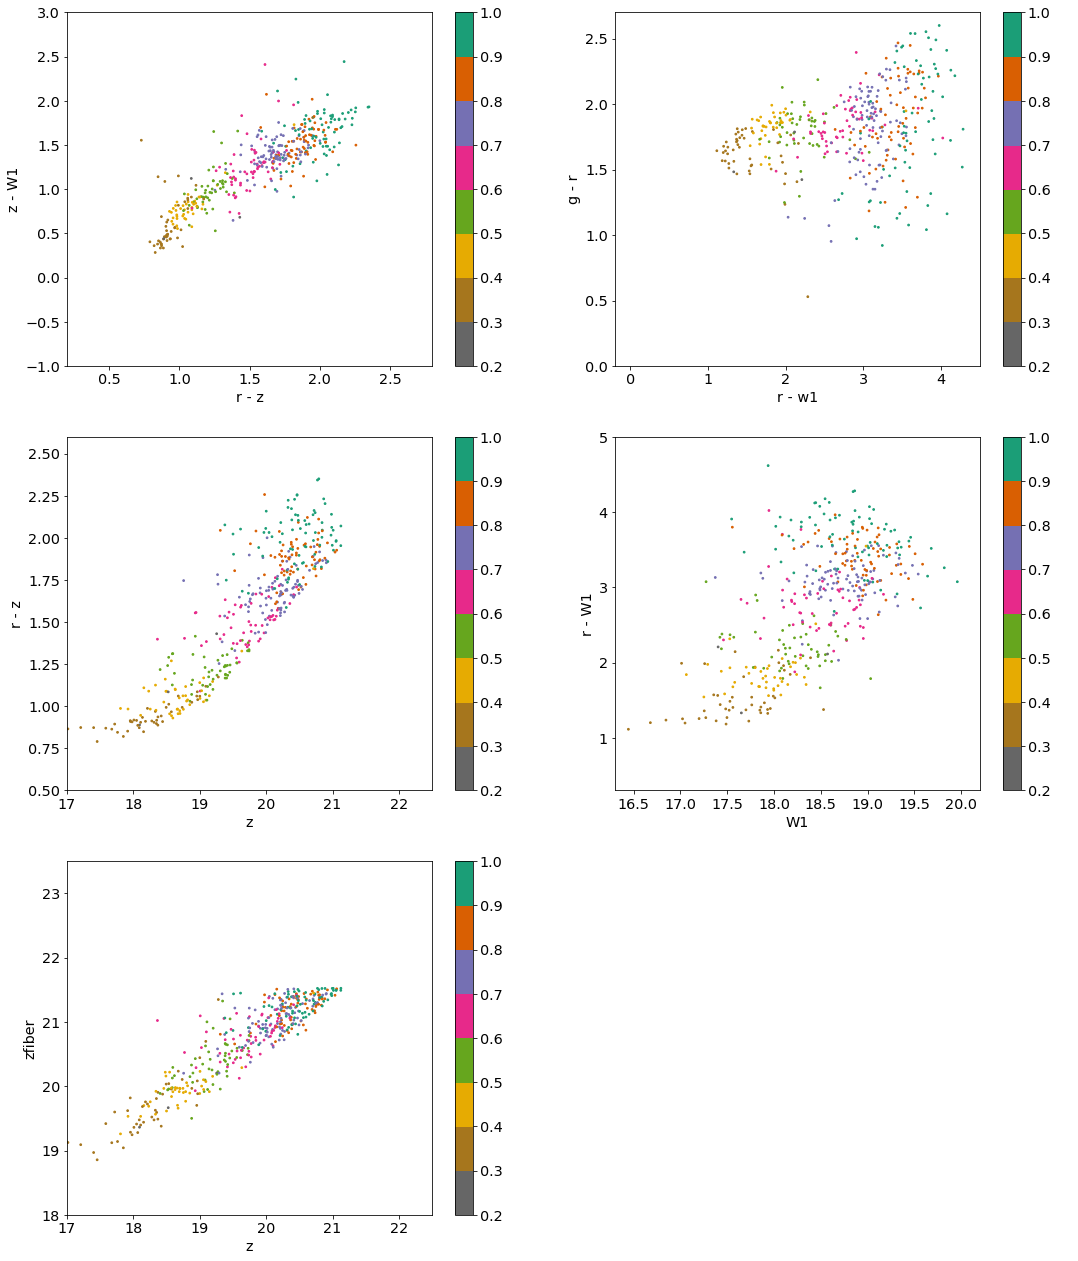

In [27]:
mask = lrg_opt & (~mask_star) & mask_zwarn
print(np.sum(mask))
lrg_plot.color_plot_3x2_new(zbest[mask], ms=3)

0


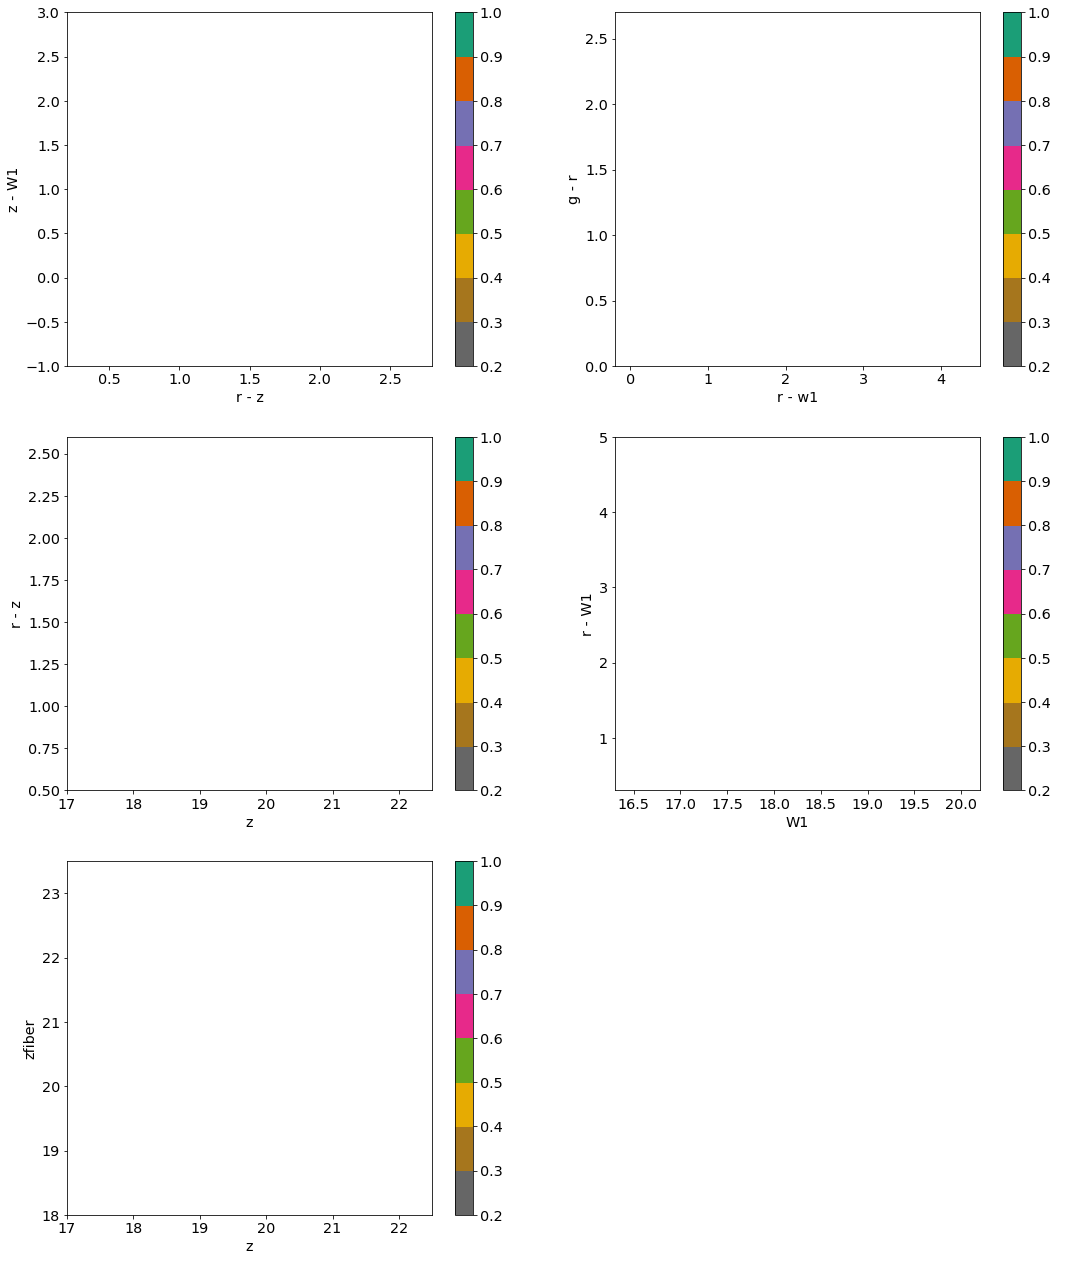

In [28]:
mask = lrg_opt & mask_star & mask_zwarn
print(np.sum(mask))
lrg_plot.color_plot_3x2_new(zbest[mask], ms=20)

1762


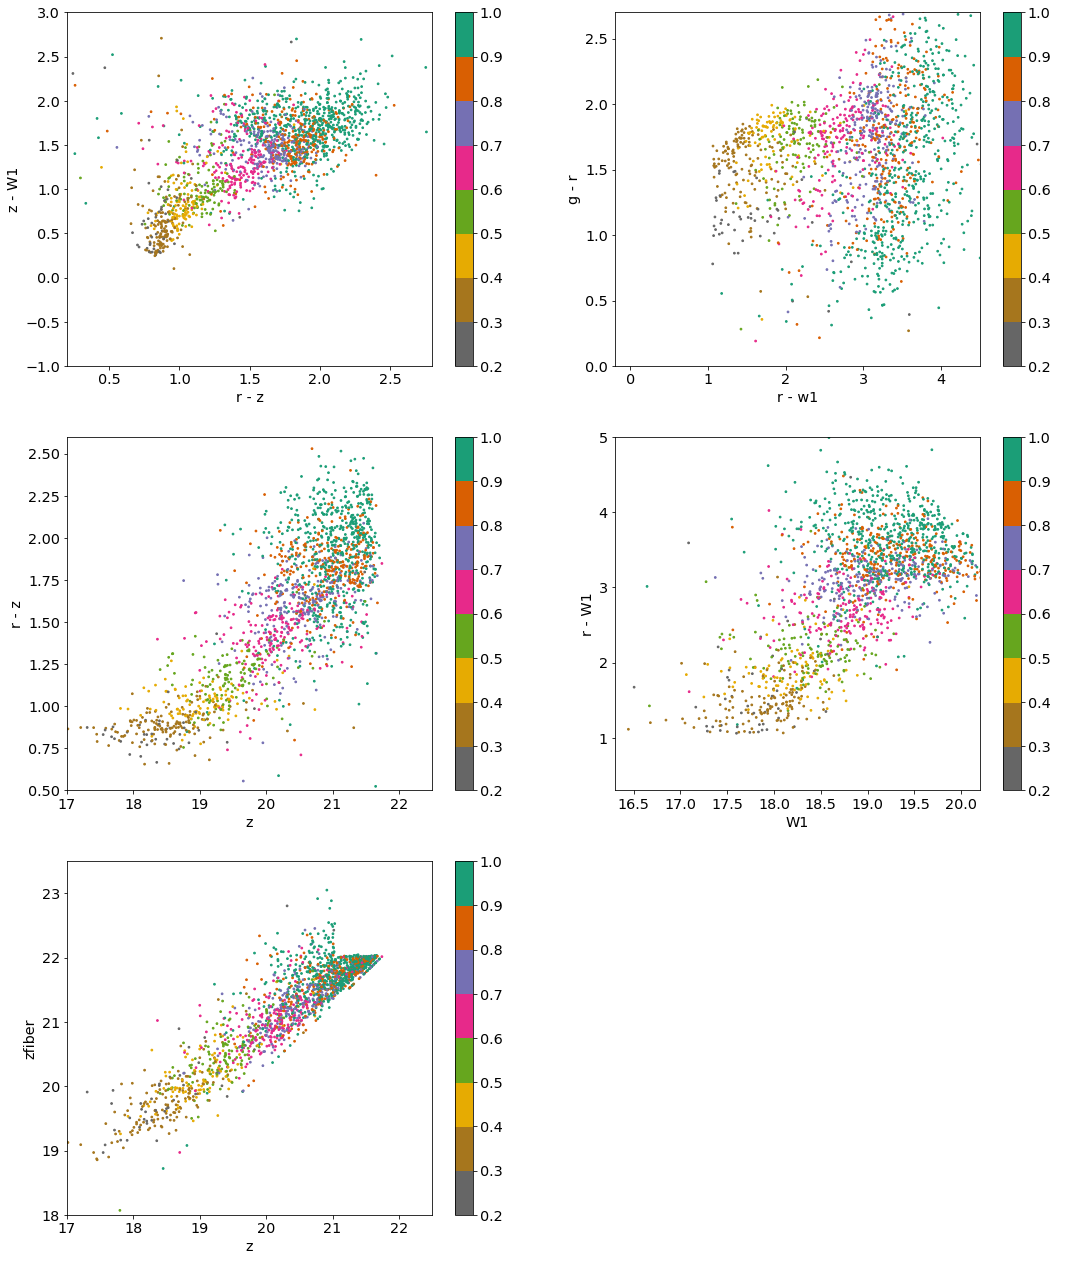

In [29]:
mask = lrg_sv & (~mask_star) & mask_zwarn
print(np.sum(mask))
lrg_plot.color_plot_3x2_new(zbest[mask], ms=3)

11


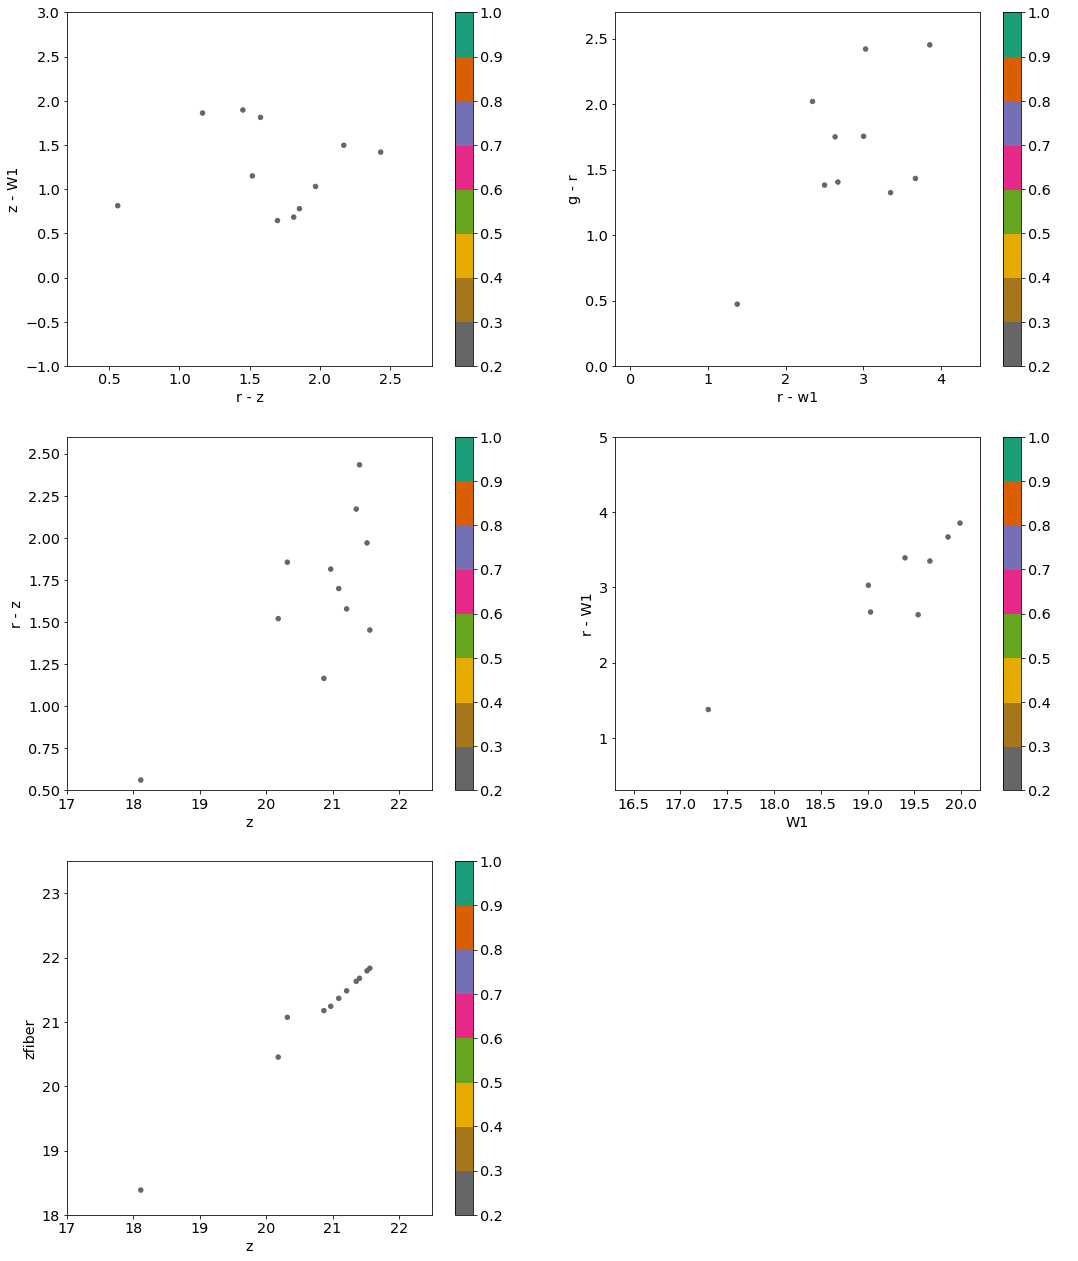

In [30]:
mask = lrg_sv & mask_star & mask_zwarn
print(np.sum(mask))
lrg_plot.color_plot_3x2_new(zbest[mask], ms=20)

In [31]:
mask = lrg_opt & mask_star & mask_zwarn
zbest[mask]

TARGETID,CHI2,COEFF [10],Z,ZERR,ZWARN,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,NUMEXP,NUMTILE,PETAL_LOC,DEVICE_LOC,LOCATION,FIBER,FIBERSTATUS,TARGET_RA,TARGET_DEC,PMRA,PMDEC,REF_EPOCH,LAMBDA_REF,FA_TARGET,FA_TYPE,OBJTYPE,FIBERASSIGN_X,FIBERASSIGN_Y,NUMTARGET,PRIORITY,SUBPRIORITY,OBSCONDITIONS,MORPHTYPE,FLUX_G,FLUX_R,FLUX_Z,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,REF_ID,REF_CAT,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_RP_MEAN_MAG,PARALLAX,EBV,FLUX_W1,FLUX_W2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,MASKBITS,SERSIC,SHAPE_R,SHAPE_E1,SHAPE_E2,PHOTSYS,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,PRIORITY_INIT,NUMOBS_INIT,RELEASE,BRICKID,BRICKNAME,BRICK_OBJID,BLOBDIST,FIBERFLUX_IVAR_G,FIBERFLUX_IVAR_R,FIBERFLUX_IVAR_Z,DESI_TARGET,BGS_TARGET,MWS_TARGET,HPXPIXEL,NUM_ITER,FIBER_X,FIBER_Y,MEAN_DELTA_X,MEAN_DELTA_Y,FIBER_RA,FIBER_DEC,COADD_NUMEXP,RMS_DELTA_X,RMS_DELTA_Y,FIRST_FIBER,LAST_FIBER,NUM_FIBER,gmag,rmag,zmag,w1mag,w2mag,gmagerr,rmagerr,zmagerr,rfibermag,zfibermag,z_phot
int64,float64,float64,float64,float64,int64,int64,bytes6,bytes20,int64,float64,int32,int32,int16,int32,int64,int32,int32,float64,float64,float32,float32,float32,float32,int64,uint8,bytes3,float32,float32,int16,int32,float64,int32,bytes4,float32,float32,float32,float32,float32,float32,int64,bytes2,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,bytes1,int64,int64,int64,int64,int64,int32,int32,bytes8,int32,float32,float32,float32,float32,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,int16,float64,float64,int64,int64,int64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64


In [32]:
mask = lrg_opt & mask_zwarn
mask &= zbest['MASKBITS'] & 2**8>0
print(np.sum(mask))
zbest[mask]

3


TARGETID,CHI2,COEFF [10],Z,ZERR,ZWARN,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,NUMEXP,NUMTILE,PETAL_LOC,DEVICE_LOC,LOCATION,FIBER,FIBERSTATUS,TARGET_RA,TARGET_DEC,PMRA,PMDEC,REF_EPOCH,LAMBDA_REF,FA_TARGET,FA_TYPE,OBJTYPE,FIBERASSIGN_X,FIBERASSIGN_Y,NUMTARGET,PRIORITY,SUBPRIORITY,OBSCONDITIONS,MORPHTYPE,FLUX_G,FLUX_R,FLUX_Z,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,REF_ID,REF_CAT,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_RP_MEAN_MAG,PARALLAX,EBV,FLUX_W1,FLUX_W2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,MASKBITS,SERSIC,SHAPE_R,SHAPE_E1,SHAPE_E2,PHOTSYS,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,PRIORITY_INIT,NUMOBS_INIT,RELEASE,BRICKID,BRICKNAME,BRICK_OBJID,BLOBDIST,FIBERFLUX_IVAR_G,FIBERFLUX_IVAR_R,FIBERFLUX_IVAR_Z,DESI_TARGET,BGS_TARGET,MWS_TARGET,HPXPIXEL,NUM_ITER,FIBER_X,FIBER_Y,MEAN_DELTA_X,MEAN_DELTA_Y,FIBER_RA,FIBER_DEC,COADD_NUMEXP,RMS_DELTA_X,RMS_DELTA_Y,FIRST_FIBER,LAST_FIBER,NUM_FIBER,gmag,rmag,zmag,w1mag,w2mag,gmagerr,rmagerr,zmagerr,rfibermag,zfibermag,z_phot
int64,float64,float64,float64,float64,int64,int64,bytes6,bytes20,int64,float64,int32,int32,int16,int32,int64,int32,int32,float64,float64,float32,float32,float32,float32,int64,uint8,bytes3,float32,float32,int16,int32,float64,int32,bytes4,float32,float32,float32,float32,float32,float32,int64,bytes2,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,bytes1,int64,int64,int64,int64,int64,int32,int32,bytes8,int32,float32,float32,float32,float32,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,int16,float64,float64,int64,int64,int64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64
39627847635046841,29394.297140970826,71.97198287402239 .. -2.8559911247352026,0.7652960142231242,8.273067163731501e-05,0,7759,GALAXY,,10,761.7895836681128,0,0,3,37,3037,1526,0,149.7350904464339,2.411861469680825,0.0,0.0,2020.9487,5400.0,41943081,1,TGT,93.671005,50.285507,0,3200,0.044915002087303035,1,DEV,0.968269,2.3265707,9.5674095,209.87999,99.18268,17.690256,0,,0.0,0.0,0.0,0.0,0.02094013,25.125689,22.831797,0.27969474,0.67205465,2.7636476,0.27981606,0.67231166,2.7639813,2816,4.0,1.624775,-0.13368683,-0.26354256,S,41943081,0,0,3200,1,0,0,,0,0.0,0.0,0.0,0.0,0,0,0,0,2,93.664,50.293,0.001666666666666667,0.0007333333333333336,0.0,0.0,15,0.007611394966320781,0.009794556311203349,1526,1526,1,22.53501,21.58321,20.048014,18.999704,19.10365,0.07128833,0.04315845,0.024850698,22.931488,21.396294,0.7652960142231242
39627853666452028,35037.774887651205,358.3887789838425 .. 13.450283729976977,0.43269102433574247,2.7631033801135712e-05,0,7747,GALAXY,,10,5609.825207412243,0,0,3,286,3286,1657,0,149.02728249522713,2.634456100177402,0.0,0.0,2020.9487,5400.0,1152921504715898985,1,TGT,271.2231,106.90367,0,3200,0.7596876115676952,7,SER,1.6091415,8.889229,23.08473,398.30475,196.91681,30.200075,0,,0.0,0.0,0.0,0.0,0.027915478,46.806137,26.928585,0.6523886,3.6039288,9.359161,0.6524107,3.604004,9.359534,256,6.0,0.91997355,-0.012538993,-0.16033368,S,1152921504715898985,65537,0,3200,1,0,0,,0,0.0,0.0,0.0,0.0,0,0,0,0,2,271.173,106.868,0.0015333333333333336,-0.002866666666666666,0.0,0.0,15,0.007487767802667673,0.008290556877154473,1657,1657,1,21.983515,20.12784,19.091688,18.324244,18.924465,0.031138526,0.008016679,0.00788263,21.108059,20.071907,0.43269102433574247
39627847668598611,23208.475985378027,131.5845269047752 .. 5.093827264292054,0.748821444094722,9.842211575776949e-05,0,7755,GALAXY,,10,1140.62574878335,0,0,7,494,7494,3813,0,151.5972616617636,2.460801804109923,0.0,0.0,2020.9487,5400.0,41943081,1,TGT,-372.3473,64.0592,0,3200,0.005504482318442028,1,DEV,0.42345166,1.9141861,9.119796,398.44092,189.70227,25.340734,0,,0.0,0.0,0.0,0.0,0.04254677,22.412022,4.0387583,0.13183679,0.5959597,2.839343,0.13682634,0.60204005,2.8502398,768,4.0,1.4316254,-0.14719439,-0.23938365,S,41943081,0,0,3200,1,0,0,,0,0.0,0.0,0.0,0.0,0,0,

----------
# Delta-chi-square

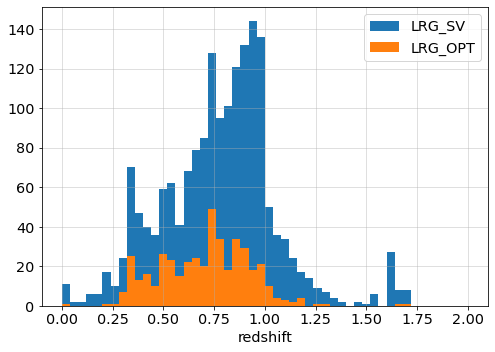

In [33]:
plt.figure(figsize=(8, 5.5))
plt.hist(zbest['Z'][lrg_sv & mask_zwarn],  50, range=(0, 2.), label='LRG_SV')
plt.hist(zbest['Z'][lrg_opt & mask_zwarn], 50, range=(0, 2.), label='LRG_OPT')
plt.xlabel('redshift')
plt.legend()
plt.grid(alpha=0.5)
plt.show()

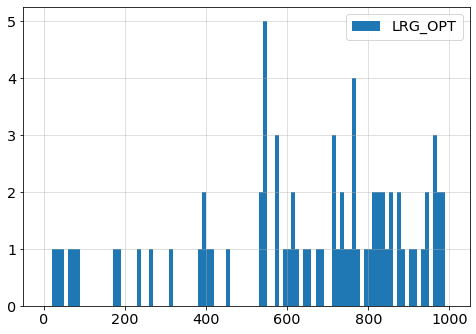

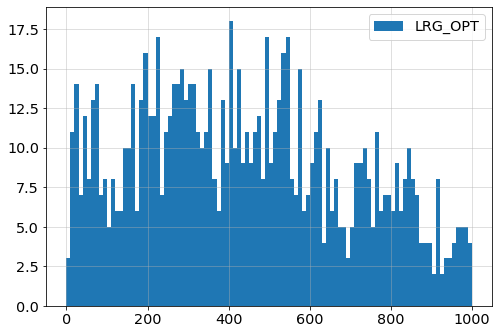

In [34]:
plt.figure(figsize=(8, 5.5))
plt.hist(zbest['DELTACHI2'][lrg_opt & mask_zwarn], 100, range=(0, 1000.), label='LRG_OPT')
# plt.xlabel('redshift')
plt.legend()
plt.grid(alpha=0.5)
plt.show()

plt.figure(figsize=(8, 5.5))
plt.hist(zbest['DELTACHI2'][lrg_sv & mask_zwarn], 100, range=(0, 1000.), label='LRG_OPT')
# plt.xlabel('redshift')
plt.legend()
plt.grid(alpha=0.5)
plt.show()

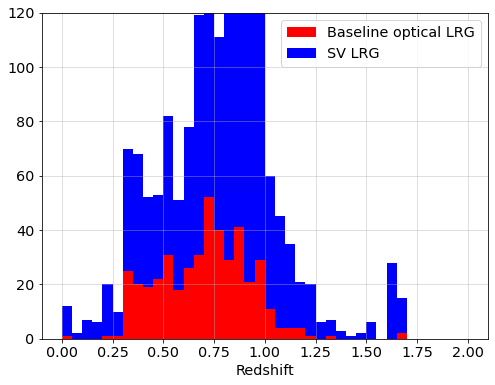

In [35]:
plt.figure(figsize=(8, 6))
plt.hist(zbest['Z'][lrg_opt & mask_zwarn], bins=40, range=(0, 2.0), color='red', label=['Baseline optical LRG'], zorder=1)
plt.hist(zbest['Z'][lrg_sv & mask_zwarn], bins=40, range=(0, 2.0), color='blue', label=['SV LRG'], zorder=0)
plt.xlabel('Redshift')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.ylim(0, 120)
plt.show()

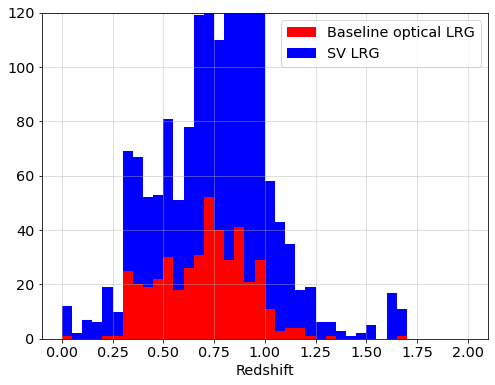

In [36]:
mask_dchi2 = zbest['DELTACHI2']>50

plt.figure(figsize=(8, 6))
plt.hist(zbest['Z'][lrg_opt & mask_zwarn & mask_dchi2], bins=40, range=(0, 2.0), color='red', label=['Baseline optical LRG'], zorder=1)
plt.hist(zbest['Z'][lrg_sv & mask_zwarn & mask_dchi2], bins=40, range=(0, 2.0), color='blue', label=['SV LRG'], zorder=0)
plt.xlabel('Redshift')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.ylim(0, 120)

plt.show()

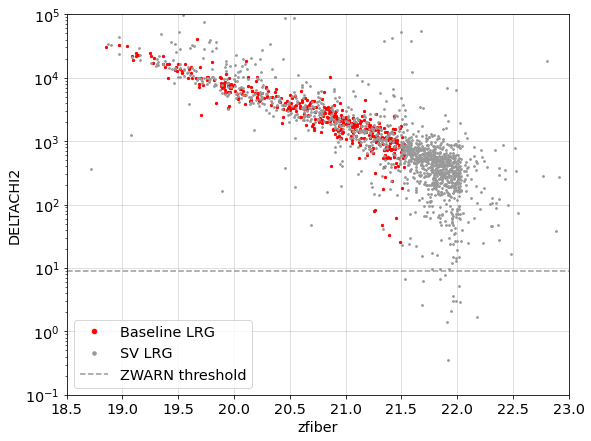

In [37]:
plt.figure(figsize=(9, 7))
plt.plot(zbest['zfibermag'][lrg_opt], zbest['DELTACHI2'][lrg_opt], 'r.', ms=4.5, alpha=1, label='Baseline LRG')
plt.plot(zbest['zfibermag'][(~lrg_opt) & lrg_sv], zbest['DELTACHI2'][(~lrg_opt) & lrg_sv], '.', color='0.6', ms=3.5, alpha=1, label='SV LRG')
plt.axhline(9., ls='--', color='0.6', label='ZWARN threshold')
plt.yscale('log')
plt.xlabel('zfiber')
plt.ylabel('DELTACHI2')
plt.axis([18.5, 23., .1, 100000])
plt.legend(markerscale=2)
plt.grid(alpha=0.5)
plt.show()

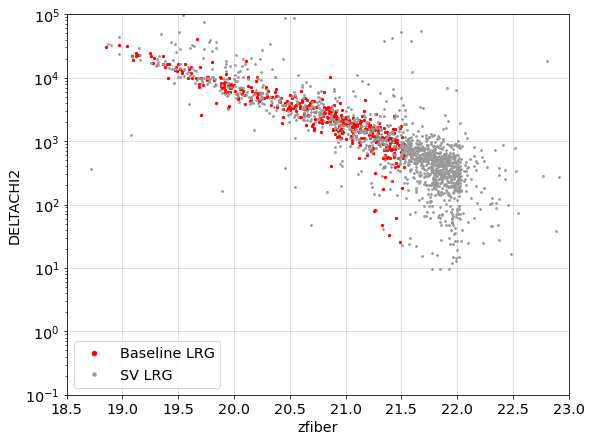

In [38]:
# Add ZWARN cut
plt.figure(figsize=(9, 7))
plt.plot(zbest['zfibermag'][lrg_opt & mask_zwarn], zbest['DELTACHI2'][lrg_opt & mask_zwarn], 'r.', ms=4.5, alpha=1, label='Baseline LRG')
plt.plot(zbest['zfibermag'][(~lrg_opt) & lrg_sv & mask_zwarn], zbest['DELTACHI2'][(~lrg_opt) & lrg_sv & mask_zwarn], 'b.', color='0.6', ms=3.5, alpha=1, label='SV LRG')
plt.yscale('log')
plt.xlabel('zfiber')
plt.ylabel('DELTACHI2')
plt.axis([18.5, 23., .1, 100000])
plt.legend(markerscale=2)
plt.grid(alpha=0.5)
plt.show()

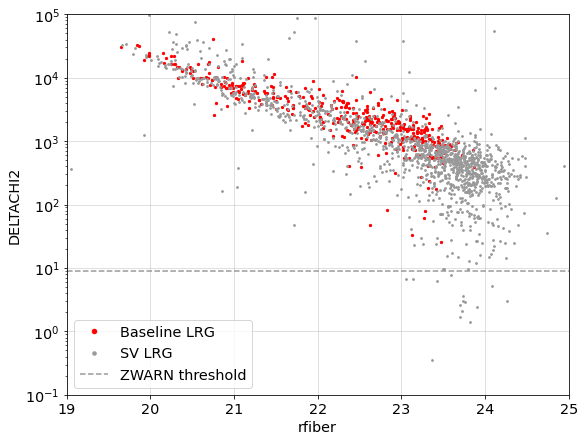

In [39]:
plt.figure(figsize=(9, 7))
plt.plot(zbest['rfibermag'][lrg_opt], zbest['DELTACHI2'][lrg_opt], 'r.', ms=4.5, alpha=1, label='Baseline LRG')
plt.plot(zbest['rfibermag'][(~lrg_opt) & lrg_sv], zbest['DELTACHI2'][(~lrg_opt) & lrg_sv], '.', color='0.6', ms=3.5, alpha=1, label='SV LRG')
plt.axhline(9., ls='--', color='0.6', label='ZWARN threshold')
plt.yscale('log')
plt.xlabel('rfiber')
plt.ylabel('DELTACHI2')
plt.axis([19, 25, .1, 100000])
plt.legend(markerscale=2)
plt.grid(alpha=0.5)
plt.show()

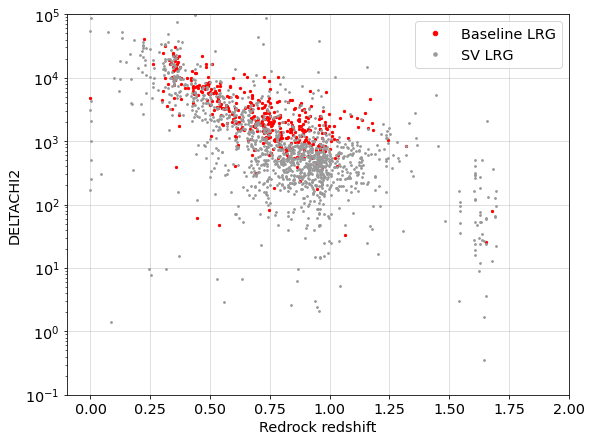

In [40]:
plt.figure(figsize=(9, 7))
plt.plot(zbest['Z'][lrg_opt], zbest['DELTACHI2'][lrg_opt], 'r.', ms=4.5, alpha=1, label='Baseline LRG')
plt.plot(zbest['Z'][(~lrg_opt) & lrg_sv], zbest['DELTACHI2'][(~lrg_opt) & lrg_sv], '.', color='0.6', ms=3.5, alpha=1, label='SV LRG')
plt.yscale('log')
plt.xlabel('Redrock redshift')
plt.ylabel('DELTACHI2')
plt.axis([-0.1, 2, .1, 100000])
plt.legend(markerscale=2)
plt.grid(alpha=0.5)
plt.show()